In [1]:
import scipy
import numpy as np
from sklearn.neighbors import KernelDensity
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import estimate_bandwidth
from sklearn.cluster import MeanShift, estimate_bandwidth

import pandas as pd

from scipy import stats
from random import randint

import matplotlib.pyplot as plt
import itertools as it

import matplotlib.pyplot as plt


import plotly
import plotly.graph_objs as go
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
init_notebook_mode(connected=True)

import collections

def recursively_default_dict():
        return collections.defaultdict(recursively_default_dict)

from matplotlib.collections import BrokenBarHCollection
import re

from structure_tools.Modules_tools import return_fsts

PCA_color_ref= ['darkseagreen','crimson', 'darkorange', 'darkblue', 'darkcyan',
            'darkgoldenrod', 'darkgray', 'darkgrey', 'darkgreen',
            'darkkhaki', 'darkmagenta', 'darkolivegreen', 'darkorange',
            'darkorchid', 'darkred', 'darksalmon', 'darkseagreen',
            'darkslateblue', 'darkslategray', 'darkslategrey',
            'darkturquoise', 'darkviolet', 'deeppink']

In [8]:
from structure_tools.vcf_geno_tools import read_geno_nanum


def proc_name(Names):
    '''locally specific de-dedoubling names.'''
    for x in range(len(Names)):
        ind= Names[x]
        newid= ind.split('_')
        if len(newid) > 2:
            newid= '_'.join(newid[:2])
        else:
            newid= newid[0]

        Names[x]= newid
    
    return Names

def pretty_input(Home= 'D:/GitHub/Tools_and_toys/VCF_analysis/Extract/vcf/', info_file= '3K_info.txt',Chr= 6, row_info= 6, header_info= 9,
                                                                                phased= False):

    filename= Home + 'Extract_Chr' + str(Chr) + '_15000.vcf'

    row_info= 6
    header_info= 9
    phased= False

    genotype, summary, Names= read_geno_nanum(filename, row_info= row_info, header_info= header_info,phased= phased)

    ## Process Names vcf names.
    ## Instance specific processing due to ID copy in VCF file.
    name_proc= 1
    if name_proc:
        Names= proc_name(Names)
        name_proc= 0


    print('Number of markers: {}'.format(genotype.shape[1]))
    print('Number of individuals: {}'.format(genotype.shape[0]))

    RG_info= pd.read_csv(info_file,sep= '\t')
    
    return genotype, summary, Names, RG_info


## Input


In [9]:

Chr= 6

genotype, summary, Names, RG_info= pretty_input(Chr= Chr)


{'fileformat': 'VCFv4.2', 'fileDate': '20190327', 'source': 'PLINKv1.90', 'contig': '<ID6,length31207416>', 'INFO': '<IDPR,Number0,TypeFlag,Description"Provisional reference allele, may not be based on real reference genome">', 'FORMAT': '<IDGT,Number1,TypeString,Description"Genotype">'}
Number of markers: 15000
Number of individuals: 3023


In [10]:

RG_info.head()

,IRIS_ID,NAME,Variety_Name_verif,COUNTRY,REGION,K9_cluster,Initial_subpop
0,B001,HEIBIAO,Heibiao,China,As6,GJ-tmp,temp
1,B002,SANSUIJIN,Sansuijin,China,As6,GJ-tmp,temp
2,B003,ZAOSHENGBAI,Zaoshengbai_,China,As6,GJ-adm,japx
3,B004,QIUGUANGTENGXI_104,Qiuguangtengxi_104_,Japan,As7,GJ-tmp,temp
4,B005,WANSHI,Wanshi,Japan,As7,GJ-tmp,temp


### Accessions of interest

In [11]:
Names_select= ['IRIS_313-10834','IRIS_313-12289','IRIS_313-8580','IRIS_313-8872','IRIS_313-9048',
              'IRIS_313-10848','IRIS_313-12029','IRIS_313-12134','IRIS_313-12265','IRIS_313-8011',
              'B014', 'B002','B008','B023','B005']



In [12]:
from tools.vcf_geno_tools_I import geno_subset_random

Sn= 400  ### accession random filter
Sm= 5000 ### snp random filter

ID_col= 'IRIS_ID'
subset_col= 'Initial_subpop'

code= {
    'ind1A':0,
    'ind1B':0,
    'ind2':0,
    'ind3':0,
    'aus':1,
    'temp':2,
    'trop':5,
    'subtrop':6,
    'aro': 3,
    'admx': 4
}


others= 'admx'

gen_sample, subsummary, code_vec, code_lib, Nsample, Msample= geno_subset_random(genotype,summary, RG_info, 
                                                                                 ID_col,subset_col, Names,code=code, include= Names_select, 
                                                                                 Sn= Sn, Sm= Sm)


15/15 of requested names present.
gen_sample shape: 414, 5000


In [13]:
from sklearn.decomposition import PCA

PCsel= 1
ref_keep= [0,1,2,3,5,6]
Names_subsel= [Names[x] for x in Nsample]
###

gp_cols= {
    0:[178,34,34,1],
    1:[255,165,0,1],
    2:[0,0,205,1],
    3:[34,139,34,1],
    4:[169,169,169],
    5:[0,0,205,1],
    6:[0,0,205,1]
}

gp_cols= {z:'rgb({})'.format(','.join([str(x) for x in g])) for z,g in gp_cols.items()}


gp_names_dict= {
    0: 'Indica',
    1: 'cAus',
    2: 'Japonica',
    3: 'cBas',
    4: 'admx',
    5: 'Japonica',
    6: 'Japonica'
}

ref_dict= list(RG_info['IRIS_ID'])
ref_dict= [ref_dict.index(x) for x in Names_subsel]
ref_code= [RG_info['Initial_subpop'][x] for x in ref_dict]

ref_dict= [['admx',x][int(x in code.keys())] for x in ref_code]
ref_dict= [code[x] for x in ref_dict]

keep_vec= [x for x in range(len(ref_dict)) if ref_dict[x] in ref_keep or Names_subsel[x] in Names_select]
names_kept= [Names_subsel[x] for x in keep_vec]
Names_idx= [names_kept.index(x) for x in Names_select]
ref_dict= [ref_dict[x] for x in keep_vec]


ref_dict= {z: [x for x in range(len(ref_dict)) if ref_dict[x]==z] for z in set(ref_dict)}
###
pca = PCA(n_components=3)

pca.fit(gen_sample[keep_vec])

pc_data= pca.transform(gen_sample[keep_vec])

###

fig= [go.Scatter3d(
    x= pc_data[g,0],
    y= pc_data[g,PCsel],
    z= pc_data[g,PCsel+1],
    text= [Names_subsel[x] for x in g],
    mode= "markers",
    name= gp_names_dict[z],
    marker= dict(
        size= 5,
        color= gp_cols[z]
    )
) for z,g in ref_dict.items()]

fig.append(go.Scatter3d(
    x= pc_data[Names_idx[:5],0],
    y= pc_data[Names_idx[:5],PCsel],
    z= pc_data[Names_idx[:5],PCsel+1],
    mode= "markers",
    name= 'interest subtrop',
    text= Names_select[:5],
    marker= dict(
        size= 5,
        color= 'rgb(30,144,255)',
        symbol= 'x',
        line= dict(width= 1)
    )
    )
)

fig.append(go.Scatter3d(
    x= pc_data[Names_idx[5:10],0],
    y= pc_data[Names_idx[5:10],PCsel],
    z= pc_data[Names_idx[5:10],PCsel+1],
    mode= "markers",
    name= 'control subtrop',
    text= Names_select[5:10],
    marker= dict(
        size= 5,
        color= 'rgb(255,215,0)',
        symbol= 'cross',
        line= dict(width= 2)
    )
    )
)

fig.append(go.Scatter3d(
    x= pc_data[Names_idx[10:],0],
    y= pc_data[Names_idx[10:],PCsel],
    z= pc_data[Names_idx[10:],PCsel+1],
    mode= "markers",
    name= 'control temp',
    text= Names_select[10:],
    marker= dict(
        size= 5,
        color= 'rgb(173,255,47)',
        symbol= 'diamond',
        line= dict(width= 2)
    )
))



layout= go.Layout()

Figure= go.Figure(data= fig,layout= layout)
iplot(Figure)


In [14]:
from sklearn.decomposition import PCA

PCsel= 1
ref_keep= [2,5,6]
Names_subsel= [Names[x] for x in Nsample]
###

gp_cols= {
    0:[178,34,34,1],
    1:[255,165,0,1],
    2:[0,128,0,1],
    3:[34,139,34,1],
    4:[169,169,169],
    5:[65,105,225,1],
    6:[128,0,128,1]
}

"""
    'red': [0,128,0],
    'yellow': [65,105,225],
    'blue': [128,0,128],
"""

gp_cols= {z:'rgb({})'.format(','.join([str(x) for x in g])) for z,g in gp_cols.items()}


gp_names_dict= {
    0: 'Indica',
    1: 'cAus',
    2: 'temp',
    3: 'cBas',
    4: 'admx',
    5: 'trop',
    6: 'subtrop'
}

ref_dict= list(RG_info['IRIS_ID'])
ref_dict= [ref_dict.index(x) for x in Names_subsel]
ref_code= [RG_info['Initial_subpop'][x] for x in ref_dict]

ref_dict= [['admx',x][int(x in code.keys())] for x in ref_code]
ref_dict= [code[x] for x in ref_dict]

keep_vec= [x for x in range(len(ref_dict)) if ref_dict[x] in ref_keep or Names_subsel[x] in Names_select]
names_kept= [Names_subsel[x] for x in keep_vec]
Names_idx= [names_kept.index(x) for x in Names_select]
ref_dict= [ref_dict[x] for x in keep_vec]


ref_dict= {z: [x for x in range(len(ref_dict)) if ref_dict[x]==z] for z in set(ref_dict)}
###
pca = PCA(n_components=3)

pca.fit(gen_sample[keep_vec])

pc_data= pca.transform(gen_sample[keep_vec])

###

fig= [go.Scatter3d(
    x= pc_data[g,0],
    y= pc_data[g,PCsel],
    z= pc_data[g,PCsel+1],
    text= [Names_subsel[x] for x in g],
    mode= "markers",
    name= gp_names_dict[z],
    marker= dict(
        size= 5,
        color= gp_cols[z]
    )
) for z,g in ref_dict.items()]

fig.append(go.Scatter3d(
    x= pc_data[Names_idx[:5],0],
    y= pc_data[Names_idx[:5],PCsel],
    z= pc_data[Names_idx[:5],PCsel+1],
    mode= "markers",
    name= 'interest subtrop',
    text= Names_select[:5],
    marker= dict(
        size= 5,
        color= 'rgb(30,144,255)',
        symbol= 'x',
        line= dict(width= 1)
    )
    )
)

fig.append(go.Scatter3d(
    x= pc_data[Names_idx[5:10],0],
    y= pc_data[Names_idx[5:10],PCsel],
    z= pc_data[Names_idx[5:10],PCsel+1],
    mode= "markers",
    name= 'control subtrop',
    text= Names_select[5:10],
    marker= dict(
        size= 5,
        color= 'rgb(255,215,0)',
        symbol= 'square',
        line= dict(width= 2)
    )
    )
)

fig.append(go.Scatter3d(
    x= pc_data[Names_idx[10:],0],
    y= pc_data[Names_idx[10:],PCsel],
    z= pc_data[Names_idx[10:],PCsel+1],
    mode= "markers",
    name= 'control temp',
    text= Names_select[10:],
    marker= dict(
        size= 5,
        color= 'rgb(173,255,47)',
        symbol= 'diamond',
        line= dict(width= 2)
    )
))



layout= go.Layout()

Figure= go.Figure(data= fig,layout= layout)
iplot(Figure)


In [40]:

def window_split_idx(genotype,summary,Steps= 25,window_size=100):

    window_starts= list(np.arange(0,genotype.shape[1],Steps))
    if window_starts[-1] != genotype.shape[1]:
        window_starts.append(genotype.shape[1])

    Windows= recursively_default_dict()
    Out= recursively_default_dict()

    lengths_winds= []

    for splyt in range(len(window_starts) - 1):
        IN= window_starts[splyt]
        OUT= window_starts[splyt] + window_size

        if OUT >= genotype.shape[1]:
            OUT= genotype.shape[1] - 1
        range_window= [IN,OUT]

        lengths_winds.append(OUT-IN)

        chrom= int(summary.CHROM[range_window[0]])

        start= int(summary.POS[range_window[0]])
        end= int(summary.POS[range_window[1]])

        Windows[chrom][start]= list(range(*range_window))
        Out[chrom][start]= end

        if OUT-IN < window_size:
            break

    return Windows, Out




In [41]:


def geno_Lwind_split(summary, geno_bornes= [],Steps= 25e3,window_size=5e4):
    '''
    split genotype array into windows by length, steps.
    assumes genotype has a single chrom.
    '''
    
    POS= np.array(summary.POS,dtype= int)
    if not geno_bornes:
        geno_bornes= [0,max(POS)]
    
    window_starts= np.array(np.arange(geno_bornes[0],geno_bornes[1],Steps),dtype=int)
    
    Windows= {}
    Out= {z: z+window_size for z in window_starts}
    
    current_winds= []
    
    for idx in range(len(POS)):
        posh= int(POS[idx])
        
        if len(window_starts):
            if window_starts[0]<= posh:
                current_winds.append(window_starts[0])
                Windows[window_starts[0]]= []
                window_starts= window_starts[1:]
        
        current_rm= []
        for windx in current_winds:
            if posh > Out[windx]:
                
                current_rm.append(windx)
                continue
            
            Windows[windx].append(idx)
        
        current_winds= [x for x in current_winds if x not in current_rm]
            
    return Windows, Out



def wind_compress(Windows,Out,min_snp= 3):
    """
    merge contiguous windows to reach minimum number of snps.
    """

    wind_sort= sorted(Windows.keys())

    new_windows= {}
    new_outs= {}

    keep= []
    n_current= 0

    for idx in range(len(wind_sort)):
        wind= wind_sort[idx]

        keep.append(wind)
        n_current+= len(Windows[wind])

        if n_current >= min_snp:
            nwind= keep[0]
            nout= Out[keep[-1]]
            poss= [Windows[x] for x in keep]
            poss= list(it.chain(*poss))

            new_windows[nwind]= poss
            new_outs[nwind]= nout
            keep= []
            n_current= 0

    return new_windows, new_outs


In [54]:
#from tools.vcf_geno_tools_II import window_split_idx
#from tools.parse_tools import geno_Lwind_split

fixed= True
##### 
if fixed:
    window_size= 120
    Steps= 10

    Windows, Out= window_split_idx(genotype,
                                    summary,
                                    Steps= Steps,
                                    window_size=window_size)

else:
    window_size= 20e3
    Steps= 5e3
    min_snp= 11
    
    geno_bornes= [subset[0] - bornes, subset[1] + bornes]
    
    Windows, Out= geno_Lwind_split(summary,geno_bornes= geno_bornes,
                                 Steps= Steps, window_size= window_size)
    
    Windows, Out= wind_compress(Windows,Out,min_snp= min_snp)
    
    Windows= {Chr: Windows}
    Out= {Chr: Out}

print('number of chromosomes: {}'.format(len(Windows)))
print('number of windows: {}'.format(sum([len(Windows[x].keys()) for x in Windows.keys()])))


number of chromosomes: 1
number of windows: 1489


In [36]:
ref_dict.keys()

dict_keys([0, 1, 2, 3, 4])

# Classification

In [68]:

    
Names_RG_info= [list(RG_info['IRIS_ID']).index(x) for x in Names_select]
Names_idx= [Names.index(x) for x in Names_select]


In [69]:
### KDE analysis across windows
from tools.KDE_tools import KDE_window_profiles

## Use result of MS classification.

ref_labels= [2,5,6]
kde_class_labels= ref_vector
n_comps= 4
Chr= 6

Sn= 90
repn= 20

from IPython.display import clear_output

Windows_profiles, var_comp_store= KDE_window_profiles(genotype,Windows,Names_idx,
                    RG_info, ID_col,subset_col,Names,
                    ref_labels, Chr= Chr,n_comps= n_comps, exclude= Names_select, gp_focus= [],
                    repn= repn, code= code,others= 'admx',Sn= Sn, same= True)



window 30965528
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [70]:

def POS_profiles_st(Windows_profiles,Out,summary, ref_labels,geno_bornes= []):
    '''
    split genotype array into windows by length, steps.
    assumes genotype has a single chrom.
    '''
    
    POS= np.array(summary.POS,dtype= int)
    
    window_starts= sorted(Windows_profiles.keys())
    window_starts= list(window_starts)
    
    
    wind_mids= {x: (Out[x] + x)/2 for x in Windows_profiles.keys()}
    
    POS_dict= {x: [] for x in ref_labels}
    
    current_winds= []
    
    for idx in range(len(POS)):
        posh= int(POS[idx])
        
        if len(window_starts):
            if window_starts[0]<= posh:
                current_winds.append(window_starts[0])
                window_starts= window_starts[1:]
        
        dist_winds= [wind_mids[x] - posh for x in current_winds]
        dist_winds= np.array(dist_winds)
        dist_winds= abs(dist_winds)
        dist_winds[dist_winds == 0] = 1
        dist_winds= 1 / dist_winds
        dist_winds= dist_winds / np.sum(dist_winds)
        
        proc_dict= {
            x: np.array([Windows_profiles[bl][x] for bl in current_winds]) for x in ref_labels
        }
        
        '''
        
        ###
        ###
        proc_dict= {
            x: np.max(g,axis= 1) for x,g in proc_max.items()
        }
        '''
        current_mids= [wind_mids[x] - posh for x in current_winds]
        if len(current_winds) > 5 and min(current_mids) < 0 and max(current_mids) > 0:
            #print([x.shape for x in proc_dict.values()])
            
            proc_dict= {z:pred_posN(g,current_mids) for z,g in proc_dict.items()}
        
        else:
            proc_max= {
                x: g.T * dist_winds for x,g in proc_dict.items()
            }


            proc_max= {x: np.argmax(g.T,axis= 0) for x,g in proc_max.items()}


            proc_dict= {
                x: [g[proc_max[x][idx],idx] for idx in range(g.shape[1])] for x,g in proc_dict.items()
            }

        for rp in ref_labels:
            POS_dict[rp].append(list(proc_dict[rp]))
        
        current_rm= []
        for windx in current_winds:
            if posh > Out[windx]:
                current_rm.append(windx)
                continue
        
        current_winds= [x for x in current_winds if x not in current_rm]
            
    return POS_dict


from scipy.interpolate import interp1d
#from scipy.signal import savgol_filter

def pred_posN(pval_array,wind_pos):
    '''
    predict pos0 given values for positions along genome.
    '''
    interp_pos= []
    
    for idx in range(pval_array.shape[1]):
        Y= pval_array[:,idx]
        #print(wind_pos)
        f2 = interp1d(wind_pos, Y, kind='cubic')
        nx= f2(0)
        
        interp_pos.append(nx)
    
    return interp_pos
        
        
        
    

In [71]:
POS_profiles= POS_profiles_st(Windows_profiles[Chr],Out[Chr],summary, ref_labels)

In [72]:
RG_info.head()

,IRIS_ID,NAME,Variety_Name_verif,COUNTRY,REGION,K9_cluster,Initial_subpop
0,B001,HEIBIAO,Heibiao,China,As6,GJ-tmp,temp
1,B002,SANSUIJIN,Sansuijin,China,As6,GJ-tmp,temp
2,B003,ZAOSHENGBAI,Zaoshengbai_,China,As6,GJ-adm,japx
3,B004,QIUGUANGTENGXI_104,Qiuguangtengxi_104_,Japan,As7,GJ-tmp,temp
4,B005,WANSHI,Wanshi,Japan,As7,GJ-tmp,temp


In [73]:
ref_labels

[2, 5, 6]

In [74]:
indi= 6
ind_name= Names_select[indi]
info_row= RG_info.loc[RG_info.IRIS_ID == ind_name]
print(info_row)

POS= np.array(summary.POS,dtype= int)

fig_s= [go.Scatter(
    x= POS,
    y= [POS_profiles[gp][pos][indi] for pos in range(len(POS))],
    name= gp,
    mode= "lines"
) for gp in ref_labels]


layout= go.Layout(
    yaxis= dict(range= [0,1])
)

Figure= go.Figure(data= fig_s,layout= layout)
iplot(Figure)

             IRIS_ID      NAME Variety_Name_verif COUNTRY REGION K9_cluster  \
2092  IRIS_313-12029  CHAO_MEO           Chao_meo    Laos    As4   GJ-sbtrp   

     Initial_subpop  
2092        subtrop  


In [76]:

def compress_ideo(df,chromosome_list, Out):
    '''
    Merge neighboring windows of the same class individual-wise. Returns pandas df.
    '''
    new_set = []
    
    for CHR in range(len(chromosome_list)):
        
        Chr = int(re.search('chr(.+?)_',chromosome_list[CHR]).group(1))
        sub = df[df.chrom == chromosome_list[CHR]]
        Coordinates = sorted(sub.start)
        Size = sub.shape[0]
        start = min(df.start)
        First = sub.gieStain.iloc[0]
        for index in range(len(Coordinates)):
            row = sub[sub.start == Coordinates[index]]
            if index == 0:
                continue
            if index == (Size - 1):
                if row.gieStain.iloc[0] == First:
                    new_set.append([chromosome_list[CHR],start,Out[Chr][max(df.start)],First])
                else:
                    new_set.append([chromosome_list[CHR],start,Out[Chr][max(df.start)],First])
                    First = row.gieStain.iloc[0]
                    start = row.start.iloc[0]
                    new_set.append([chromosome_list[CHR],start,Out[Chr][max(df.start)],First])
            else:
                if row.gieStain.iloc[0] == First:
                    continue
                else:
                    new_set.append([chromosome_list[CHR],start,row.start.iloc[0]-1,First])
                    First = row.gieStain.iloc[0]
                    start = row.start.iloc[0]
    
    new_set = pd.DataFrame(new_set,columns = ['chrom', 'start', 'end', 'gieStain'])
    return new_set




def class_and_ideo(Windows_profiles,Out,label_vector,Comparison_threshold= 3,Outlier_threshold= 1e-4,groups_plot=[0],colors= 'standard',
                  alt_col= []):
    
    print(label_vector)
    label_coords= {
        z:[x for x in range(len(label_vector)) if label_vector[x] == z] for z in list(set(label_vector))
    }

    focus_indexes= list(it.chain(*[label_coords[x] for x in groups_plot]))

    if colors== 'standard':
        color_ref= ['red','yellow','blue','black','orange','purple','green','silver','silver','red3','deepskyeblue','navy','chartreuse','darkorchid3','goldenrod2']
    else:
        color_ref= alt_col
    
    print(focus_indexes)
    Blocks = Merge_class(Windows_profiles,focus_indexes,Out,Comparison_threshold,Outlier_threshold)

    Ideo_KDE = []
    chromosome_list= []
    chromosomes= Blocks.keys()

    for here in range(len(focus_indexes)):
        Subject = 'sample' + str(focus_indexes[here])

        chromosome_list.extend(['Region_chr'+str(Chr)+ '_' + Subject for Chr in chromosomes])

        Stock = [[['Region_chr'+str(Chr)+ '_' + Subject,bl,Out[Chr][bl],color_ref[Blocks[Chr][bl][here] - 1]] for bl in sorted(Blocks[Chr].keys())] for Chr in chromosomes]
        Stock = [y for y in it.chain(*[z for z in it.chain(*[Stock])])]

        Ideo_KDE.extend(Stock)

    #### begin by compressing assignments by individuals. Lightens the load of the following plot.
    import re
    ideo_kde = pd.DataFrame(Ideo_KDE,columns = ['chrom', 'start', 'end', 'gieStain'])

    # Filter out chromosomes not in our list
    ideo_kde = ideo_kde[ideo_kde.chrom.apply(lambda x: x in chromosome_list)]

    ideo_kde = compress_ideo(ideo_kde,chromosome_list,Out)

    return Blocks, ideo_kde, chromosome_list


####################################################
### Classification of KDE collections

def Merge_class(Ref_profiles,focus_indicies,Out,Diff_threshold,X_threshold):
    Blocks_genome = recursively_default_dict()
    
    for CHR in Ref_profiles.keys():
        
        Points = sorted(Out[CHR].keys())
        Likes = Ref_profiles[CHR]
        N_pops= len(Likes[[x for x in Likes.keys()][0]])
        Pop_labels= Likes[[x for x in Likes.keys()][0]].keys()
        
        Likes = {x:[Likes[bl][x] for bl in sorted(Likes.keys())] for x in Pop_labels}
        
        #Likes = {x:np.array([y[0] for y in Likes[x]]) for x in Likes.keys()}
        Likes = {x:np.array(y) for x,y in Likes.items()}

        Topo = []
        
        #range_Parents = [x + Aro.shape[0] for x in range(Daddy.shape[0])]
        #range_Crossed = [x for x in range(Aro.shape[0])]
        
        for acc in focus_indicies:
            
            Guys = np.array([Likes[x][:,acc] for x in Pop_labels])
            Guys = np.nan_to_num(Guys)
            Guys = [[[y,0][int(y<=X_threshold)] for y in x] for x in Guys]
            
            Test = [int(x <= X_threshold) for x in np.amax(np.array(Guys),axis = 0)]     
            
            #
            Guys = np.array(Guys).T
            
            maxim = np.argmax(Guys,axis = 1)
            where_X = [x for x in range(Guys.shape[0]) if Test[x] == 1]
            
            #
            Consex = [x for x in it.combinations(range(N_pops),2)]
            if Consex:
                for h in range(len(maxim)):
                    CL = []
                    for j in Consex:
                        Diff = Guys[h,j]
                        if maxim[h] not in j or len([x for x in Diff if x < X_threshold]) > 0:
                            continue
                        if max(Diff) <= X_threshold:
                            Diff = 0
                        else:
#                            Diff = int(len([x for x in Diff if x <= Diff_threshold]) == 1)
                            Diff = abs(max(Diff)) / abs(min(Diff))
                            Diff = int(Diff > Diff_threshold)
                        
                        if Diff == 0:
                            CL.append(j)
                    
                    if len(CL) == 2:
                        maxim[h] = 7
                    if len(CL) == 1:
                        maxim[h] = sum(CL[0]) + N_pops
            
            maxim[where_X] = N_pops
            
            if not Consex:
                for h in range(len(maxim)):
                    #maxim[h] = int(10*Guys[h,0])
                    maxim[h]= int(Guys[h,0] <= X_threshold)
            
            
            Topo.append(maxim + 1)
        
        
        Topo = np.array(Topo).T
        print(Topo.shape)
        Clove = {CHR:{Points[x]:Topo[x,] for x in range(len(Points))}}
        
        Blocks_genome.update(Clove)
    
    return Blocks_genome

In [77]:
#from structure_tools.Sim_ideogram_tools import compress_ideo, class_and_ideo


Comparison_threshold= 4
Outlier_threshold= 1e-5

colors= 'standard'
alt_col= PCA_color_ref

groups_plot= [0]

Blocks, ideo_kde, chromosome_list = class_and_ideo(Windows_profiles,Out,[0]*len(Names_select),
                         Comparison_threshold= Comparison_threshold,
                         Outlier_threshold= Outlier_threshold,
                         groups_plot=groups_plot,
                         colors= 'standard',
                         alt_col= alt_col)


[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
(1489, 15)


In [96]:

def return_ideogram(ideo, chromosome_list,ID,color_lookup= {},out= True,height=30,width= 10,
                    xticks= 100000,ypad= 30,xpad=10,xfont= 10, yfont= 25,start= 0,end= 0,square= False):
    # Height of each ideogram
    chrom_height = 1

    # Spacing between consecutive ideograms
    chrom_spacing = 0

    # Height of the gene track. Should be smaller than `chrom_spacing` in order to
    # fit correctly
    gene_height = 0.0

    # Padding between the top of a gene track and its corresponding ideogram
    gene_padding = 0.0


    # Keep track of the y positions for ideograms and genes for each chromosome,
    # and the center of each ideogram (which is where we'll put the ytick labels)
    ybase = 0
    chrom_ybase = {}
    gene_ybase = {}
    chrom_centers = {}

    # Iterate in reverse so that items in the beginning of `chromosome_list` will
    # appear at the top of the plot
    for chrom in chromosome_list[::-1]:
        chrom_ybase[chrom] = ybase
        chrom_centers[chrom] = ybase + chrom_height / 2.
        gene_ybase[chrom] = ybase - gene_height - gene_padding
        ybase += chrom_height + chrom_spacing



    # Keep track of the y positions for ideograms and genes for each chromosome,
    # and the center of each ideogram (which is where we'll put the ytick labels)
    ybase = 0
    chrom_ybase = {}
    gene_ybase = {}
    chrom_centers = {}

    # Iterate in reverse so that items in the beginning of `chromosome_list` will
    # appear at the top of the plot
    for chrom in chromosome_list[::-1]:
        chrom_ybase[chrom] = ybase
        chrom_centers[chrom] = ybase + chrom_height / 2.
        gene_ybase[chrom] = ybase - gene_height - gene_padding
        ybase += chrom_height + chrom_spacing
    

    # Colors for different chromosome stains
    if not color_lookup:
        
        color_lookup = {
            'red': [255, 0, 0],
            'yellow': [255, 255, 0],
            'blue': [0, 0, 255],
            'orange': [255, 165, 0],
            'green': [50, 205, 50],
            'black': [0, 0, 0],
            'purple': [128, 0, 128],
            'silver': [211, 211, 211],
        }

    # Add a new column for colors
    
    ideo['colors'] = ideo['gieStain'].apply(lambda x: tuple([round(y / float(255),1) for y in color_lookup[x]]))
    # Add a new column for width
    ideo['width'] = ideo.end - ideo.start

    # Width, height (in inches)
    figsize = (width, height)

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)
    
    if square:
        from matplotlib.patches import Rectangle
        someX= start
        someY= -1

        currentAxis= plt.gca()
        currentAxis.add_patch(Rectangle((someX,someY),
        end-start,len(chromosome_list) + 2,
        fill= None, alpha= 1, linewidth= 5))


    # Now all we have to do is call our function for the ideogram data...
    print("adding ideograms...")
    for collection in chromosome_collections(ideo, chrom_ybase, chrom_height, edgecolors=None, linewidths= 0):
        ax.add_collection(collection)

    # Axes tweaking
    ax.set_xticks([x for x in range(min(ideo.start),max(ideo.end),int(xticks))])
    ax.set_xticklabels([round(x,3) for x in range(min(ideo.start),max(ideo.end),int(xticks))])
    plt.xticks(fontsize = xfont,rotation = 90)
    ax.tick_params(axis = 'x',pad= xpad)

    ax.tick_params(axis='y', which='major', pad= ypad)
    ax.set_yticks([chrom_centers[i] for i in chromosome_list])
    
    ax.set_yticklabels(chromosome_list, fontsize = yfont)
    ax.axis('tight')
    if out == True:
        plt.savefig('Ideo_step_' + '_' + ID + '.png',bbox_inches = 'tight')
    plt.show()
    plt.close()
    return fig




In [97]:
color_lookup = {
    'red': [0,128,0],
    'yellow': [65,105,225],
    'blue': [128,0,128],
    'orange': [211, 211, 211],
    'green': [211, 211, 211],
    'black': [0, 0, 0],
    'purple': [211, 211, 211],
    'silver': [211, 211, 211],
}

adding ideograms...


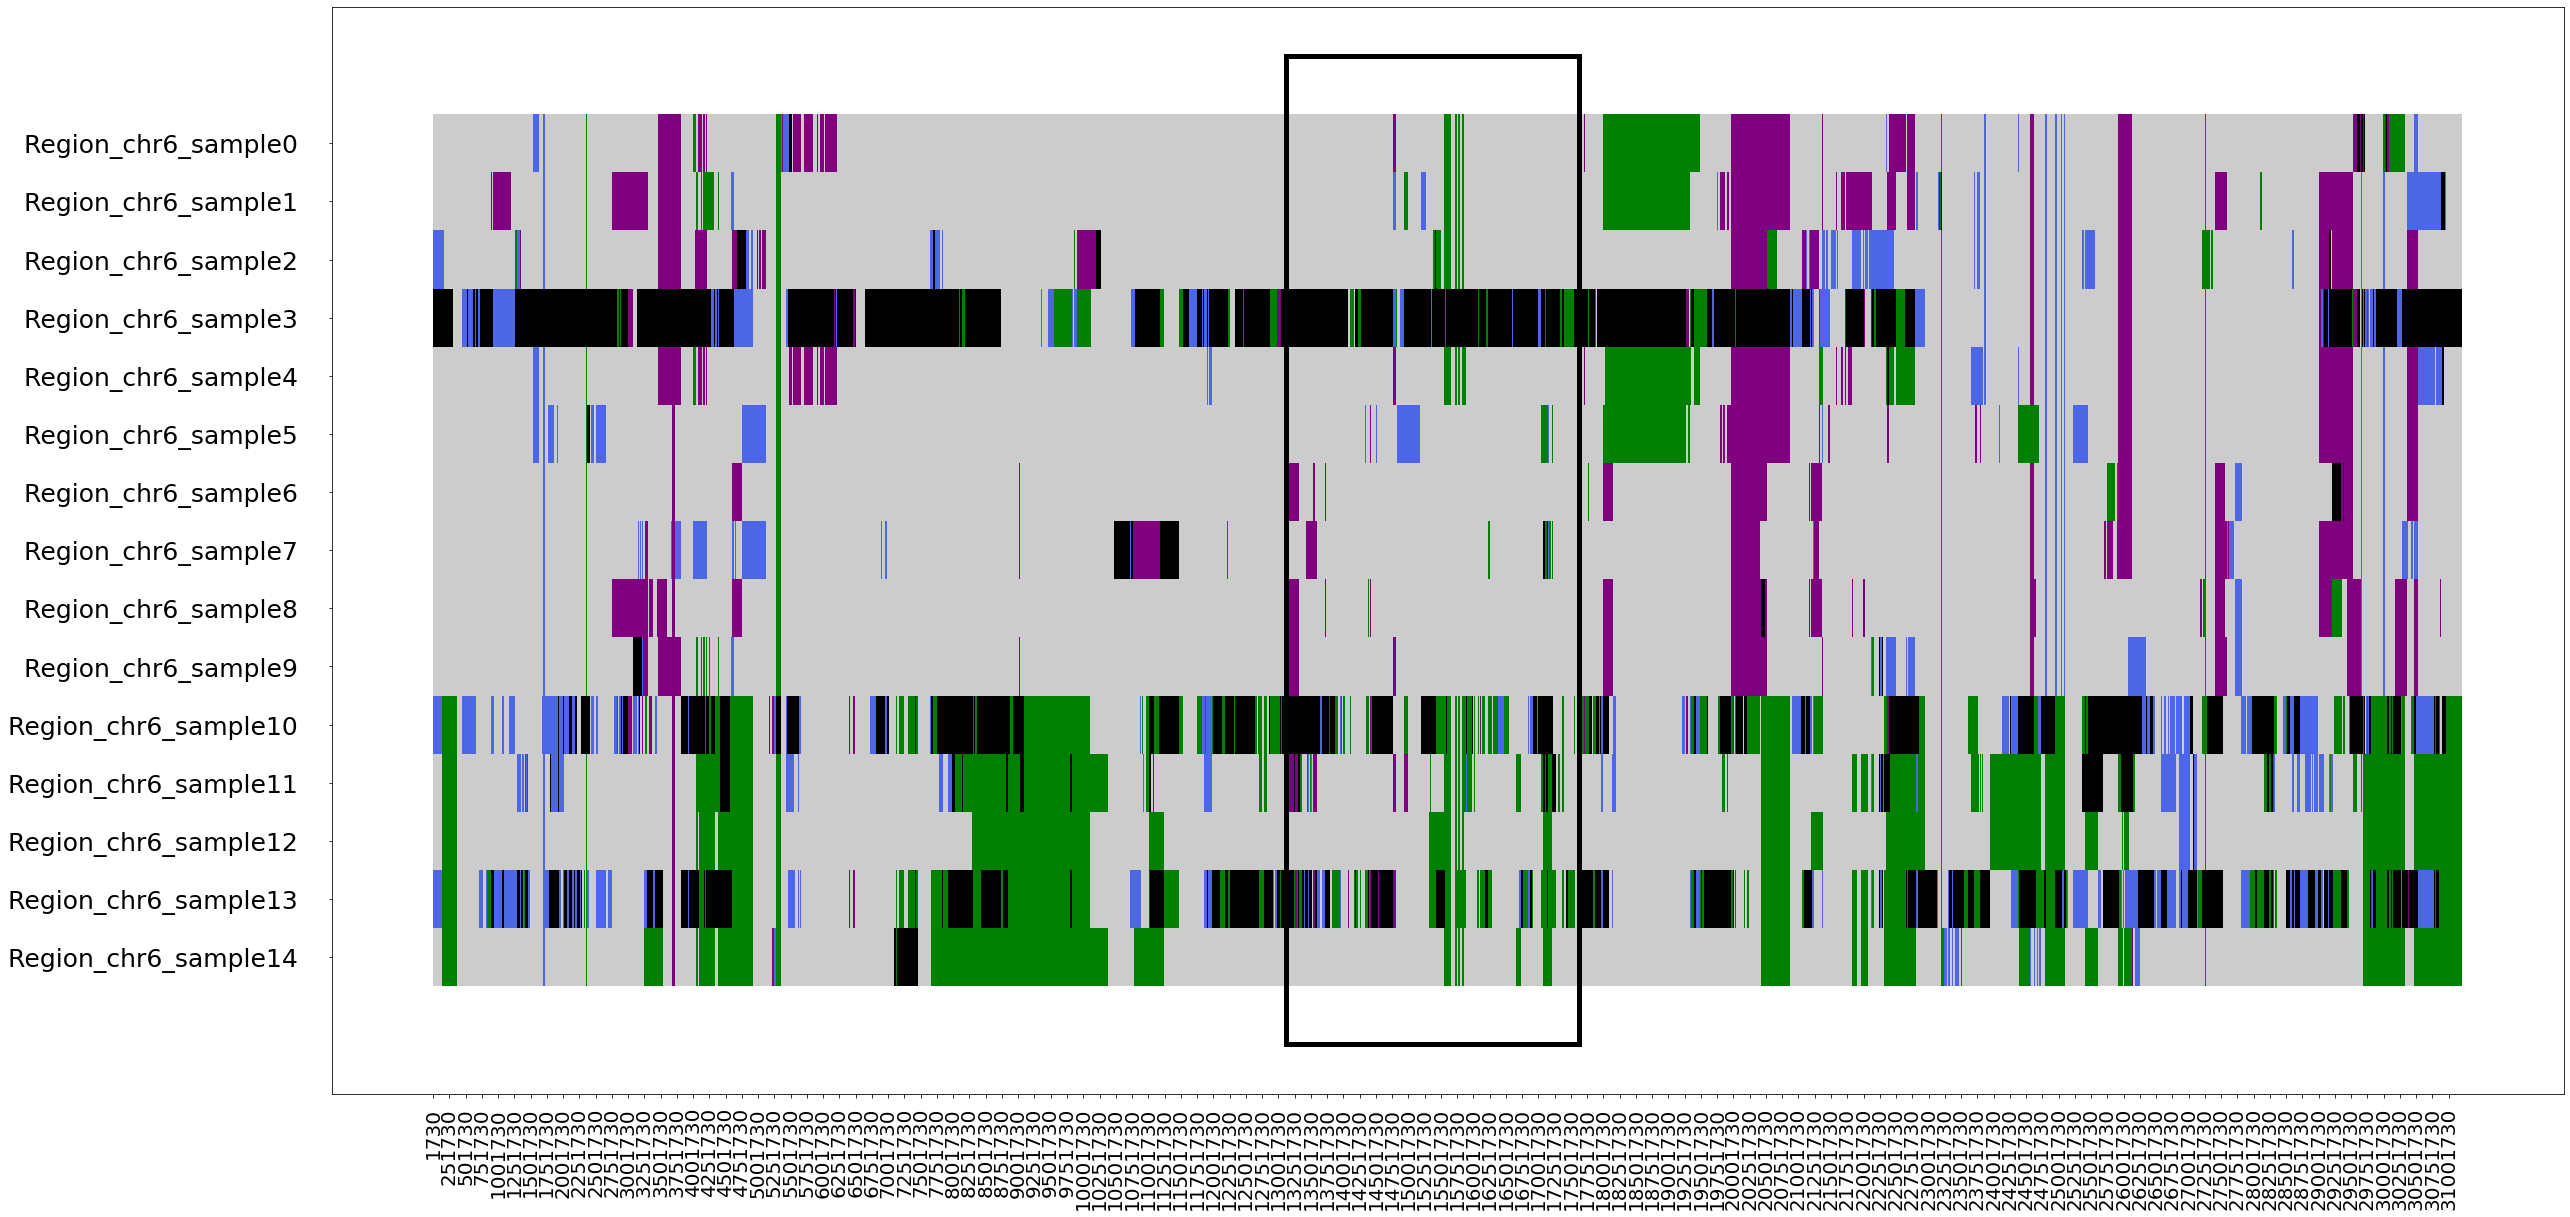

In [99]:
#from structure_tools.Sim_ideogram_tools import return_ideogram
from structure_tools.Sim_ideogram_tools import chromosome_collections
ID= 'kdeREGref_Struct_gp{}_w{}_N{}_M{}_th{}'.format('-'.join([str(x) for x in groups_plot]),Sn,Sm,window_size,Comparison_threshold)  

subset= [13119682,17632495]

Fig_ideo= return_ideogram(ideo_kde,chromosome_list,ID,color_lookup= color_lookup,
                          height= 20,width= 40,yfont= 25,square= True, start= subset[0],end= subset[1],
                             xticks= 2.5e5,xfont= 20)


## Closing in on the inversion.

In [100]:
subset= [13119682,17632495]

bornes= 5e3

if len(subset):
    
    pos_sub= np.array(summary.POS,dtype= int)
    pos_sub= (pos_sub > (subset[0] - bornes)) & (pos_sub <= (subset[1] + bornes))
    
    summary= summary[pos_sub]
    summary= summary.reset_index(drop= True)
    
    genotype= genotype[:,pos_sub]

In [104]:
#from tools.vcf_geno_tools_II import window_split_idx
#from tools.parse_tools import geno_Lwind_split

fixed= True
##### 
if fixed:
    window_size= 120
    Steps= 5

    Windows, Out= window_split_idx(genotype,
                                    summary,
                                    Steps= Steps,
                                    window_size=window_size)

else:
    window_size= 20e3
    Steps= 5e3
    min_snp= 11
    
    geno_bornes= [subset[0] - bornes, subset[1] + bornes]
    
    Windows, Out= geno_Lwind_split(summary,geno_bornes= geno_bornes,
                                 Steps= Steps, window_size= window_size)
    
    Windows, Out= wind_compress(Windows,Out,min_snp= min_snp)
    
    Windows= {Chr: Windows}
    Out= {Chr: Out}

print('number of chromosomes: {}'.format(len(Windows)))
print('number of windows: {}'.format(sum([len(Windows[x].keys()) for x in Windows.keys()])))


number of chromosomes: 1
number of windows: 494


In [105]:
### KDE analysis across windows
from tools.KDE_tools import KDE_window_profiles

## Use result of MS classification.

ref_labels= [2,5,6]
kde_class_labels= ref_vector
n_comps= 4
Chr= 6

Sn= 90
repn= 20

from IPython.display import clear_output

Windows_profiles, var_comp_store= KDE_window_profiles(genotype,Windows,Names_idx,
                    RG_info, ID_col,subset_col,Names,
                    ref_labels, Chr= Chr,n_comps= n_comps, exclude= Names_select, gp_focus= [],
                    repn= repn, code= code,others= 'admx',Sn= Sn, same= True)



window 17436964
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [112]:
#from structure_tools.Sim_ideogram_tools import compress_ideo, class_and_ideo


Comparison_threshold= 4
Outlier_threshold= 1e-5

colors= 'standard'
alt_col= PCA_color_ref

groups_plot= [0]

Blocks, ideo_kde, chromosome_list = class_and_ideo(Windows_profiles,Out,[0]*len(Names_select),
                         Comparison_threshold= Comparison_threshold,
                         Outlier_threshold= Outlier_threshold,
                         groups_plot=groups_plot,
                         colors= 'standard',
                         alt_col= alt_col)


[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
(494, 15)


adding ideograms...


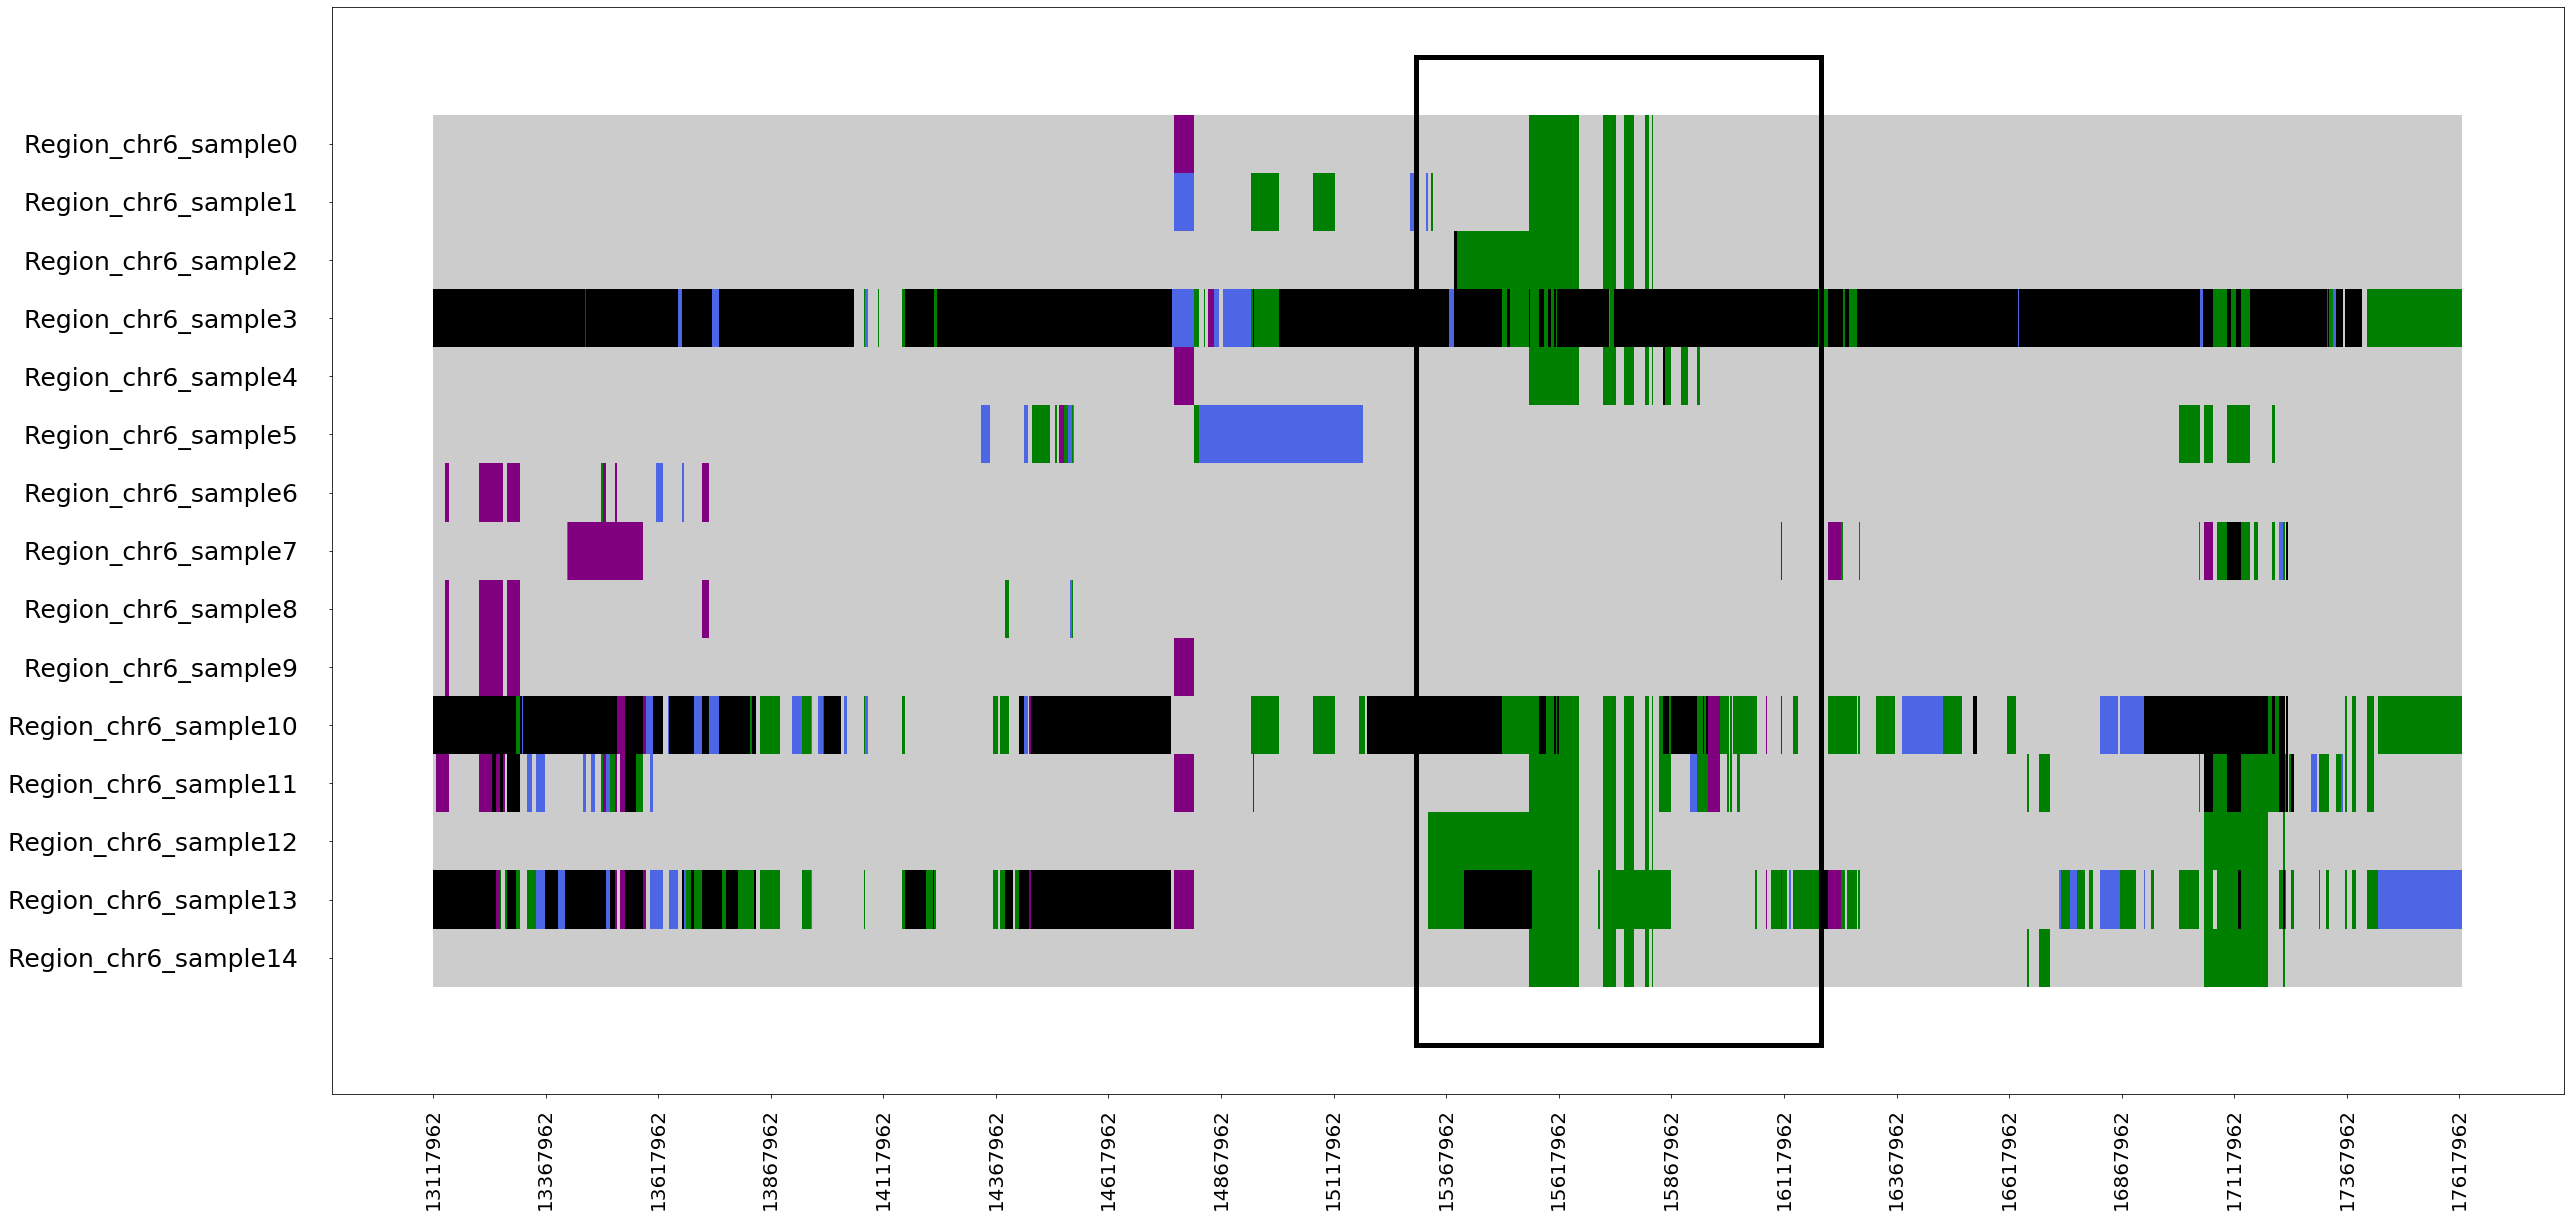

In [113]:
#from structure_tools.Sim_ideogram_tools import return_ideogram
from structure_tools.Sim_ideogram_tools import chromosome_collections
ID= 'kdeINV_Struct_gp{}_w{}_N{}_M{}_th{}'.format('-'.join([str(x) for x in groups_plot]),Sn,Sm,window_size,Comparison_threshold)  

subset= [15300000,16200000]

Fig_ideo= return_ideogram(ideo_kde,chromosome_list,ID,color_lookup= color_lookup,
                          height= 20,width= 40,yfont= 25,square= True, start= subset[0],end= subset[1],
                             xticks= 2.5e5,xfont= 20)


In [ ]:
print(genotype.shape)

In [114]:
bornes= 5e3

if len(subset):
    
    pos_sub= np.array(summary.POS,dtype= int)
    pos_sub= (pos_sub > (subset[0] - bornes)) & (pos_sub <= (subset[1] + bornes))
    
    summary= summary[pos_sub]
    summ_spec= summary.reset_index(drop= True)
    
    gen_spec= genotype[:,pos_sub]

In [116]:
from sklearn.decomposition import PCA

PCsel= 1
ref_keep= [2,5,6]
Names_subsel= Names
###

gp_cols= {
    0:[178,34,34,1],
    1:[255,165,0,1],
    2:[0,128,0,1],
    3:[34,139,34,1],
    4:[169,169,169],
    5:[65,105,225,1],
    6:[128,0,128,1]
}


gp_cols= {z:'rgb({})'.format(','.join([str(x) for x in g])) for z,g in gp_cols.items()}


gp_names_dict= {
    0: 'Indica',
    1: 'cAus',
    2: 'temp',
    3: 'cBas',
    4: 'admx',
    5: 'trop',
    6: 'subtrop'
}

ref_dict= list(RG_info['IRIS_ID'])
ref_dict= [ref_dict.index(x) for x in Names_subsel]
ref_code= [RG_info['Initial_subpop'][x] for x in ref_dict]

ref_dict= [['admx',x][int(x in code.keys())] for x in ref_code]
ref_dict= [code[x] for x in ref_dict]

keep_vec= [x for x in range(len(ref_dict)) if ref_dict[x] in ref_keep or Names_subsel[x] in Names_select]
names_kept= [Names_subsel[x] for x in keep_vec]
Names_idx= [names_kept.index(x) for x in Names_select]
ref_dict= [ref_dict[x] for x in keep_vec]


ref_dict= {z: [x for x in range(len(ref_dict)) if ref_dict[x]==z] for z in set(ref_dict)}
###
pca = PCA(n_components=3)

pca.fit(gen_spec[keep_vec])

pc_data= pca.transform(gen_spec[keep_vec])

###

fig= [go.Scatter3d(
    x= pc_data[g,0],
    y= pc_data[g,PCsel],
    z= pc_data[g,PCsel+1],
    text= [Names_subsel[x] for x in g],
    mode= "markers",
    name= gp_names_dict[z],
    marker= dict(
        size= 5,
        color= gp_cols[z]
    )
) for z,g in ref_dict.items()]

fig.append(go.Scatter3d(
    x= pc_data[Names_idx[:5],0],
    y= pc_data[Names_idx[:5],PCsel],
    z= pc_data[Names_idx[:5],PCsel+1],
    mode= "markers",
    name= 'interest subtrop',
    text= Names_select[:5],
    marker= dict(
        size= 5,
        color= 'rgb(30,144,255)',
        symbol= 'x',
        line= dict(width= 1)
    )
    )
)

fig.append(go.Scatter3d(
    x= pc_data[Names_idx[5:10],0],
    y= pc_data[Names_idx[5:10],PCsel],
    z= pc_data[Names_idx[5:10],PCsel+1],
    mode= "markers",
    name= 'control subtrop',
    text= Names_select[5:10],
    marker= dict(
        size= 5,
        color= 'rgb(255,215,0)',
        symbol= 'square',
        line= dict(width= 2)
    )
    )
)

fig.append(go.Scatter3d(
    x= pc_data[Names_idx[10:],0],
    y= pc_data[Names_idx[10:],PCsel],
    z= pc_data[Names_idx[10:],PCsel+1],
    mode= "markers",
    name= 'control temp',
    text= Names_select[10:],
    marker= dict(
        size= 5,
        color= 'rgb(173,255,47)',
        symbol= 'diamond',
        line= dict(width= 2)
    )
))



layout= go.Layout()

Figure= go.Figure(data= fig,layout= layout)
iplot(Figure)
